# 03 — Dynamic Pricing Insight

**Objective:** Analyze the relationship between lead time, seasonality, and pricing (ADR) to identify optimal pricing windows and revenue maximization strategies.

---

## 1. Setup & Data Preparation

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import COLORS, MONTH_ORDER, FIGURES_PATH, DATA_PATH, LEAD_TIME_LABELS
from src.data_cleaning import load_raw_data, clean_data
from src.feature_engineering import add_features
from src.viz_style import set_theme, format_axis_currency, GOLD_CMAP

set_theme()

raw = load_raw_data(DATA_PATH)
df = clean_data(raw)
df = add_features(df)

# Focus on non-canceled bookings for pricing analysis
active = df[df['is_canceled'] == 0].copy()
print(f'Active bookings: {len(active):,}')

Active bookings: 75,165


## 2. Lead Time vs ADR Relationship

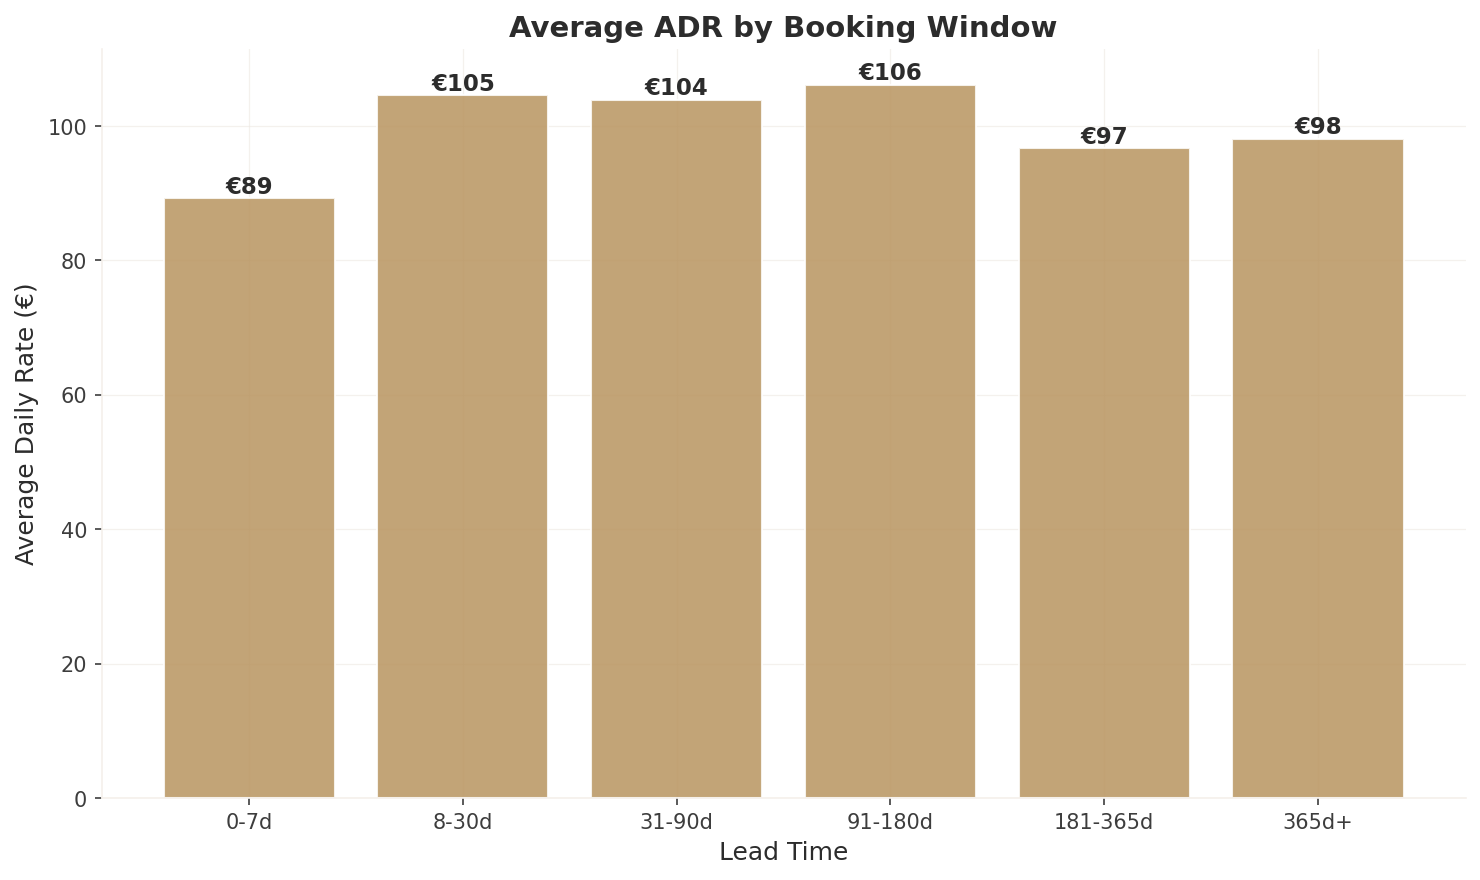

In [2]:
# ADR by booking window
adr_by_window = active.groupby('booking_window', observed=False)['adr'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(adr_by_window['booking_window'].astype(str), adr_by_window['mean'],
              color=COLORS['primary'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, adr_by_window['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'€{val:.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=COLORS['dark'])
ax.set_title('Average ADR by Booking Window', fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time')
ax.set_ylabel('Average Daily Rate (€)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}12_adr_by_window.png')
plt.show()

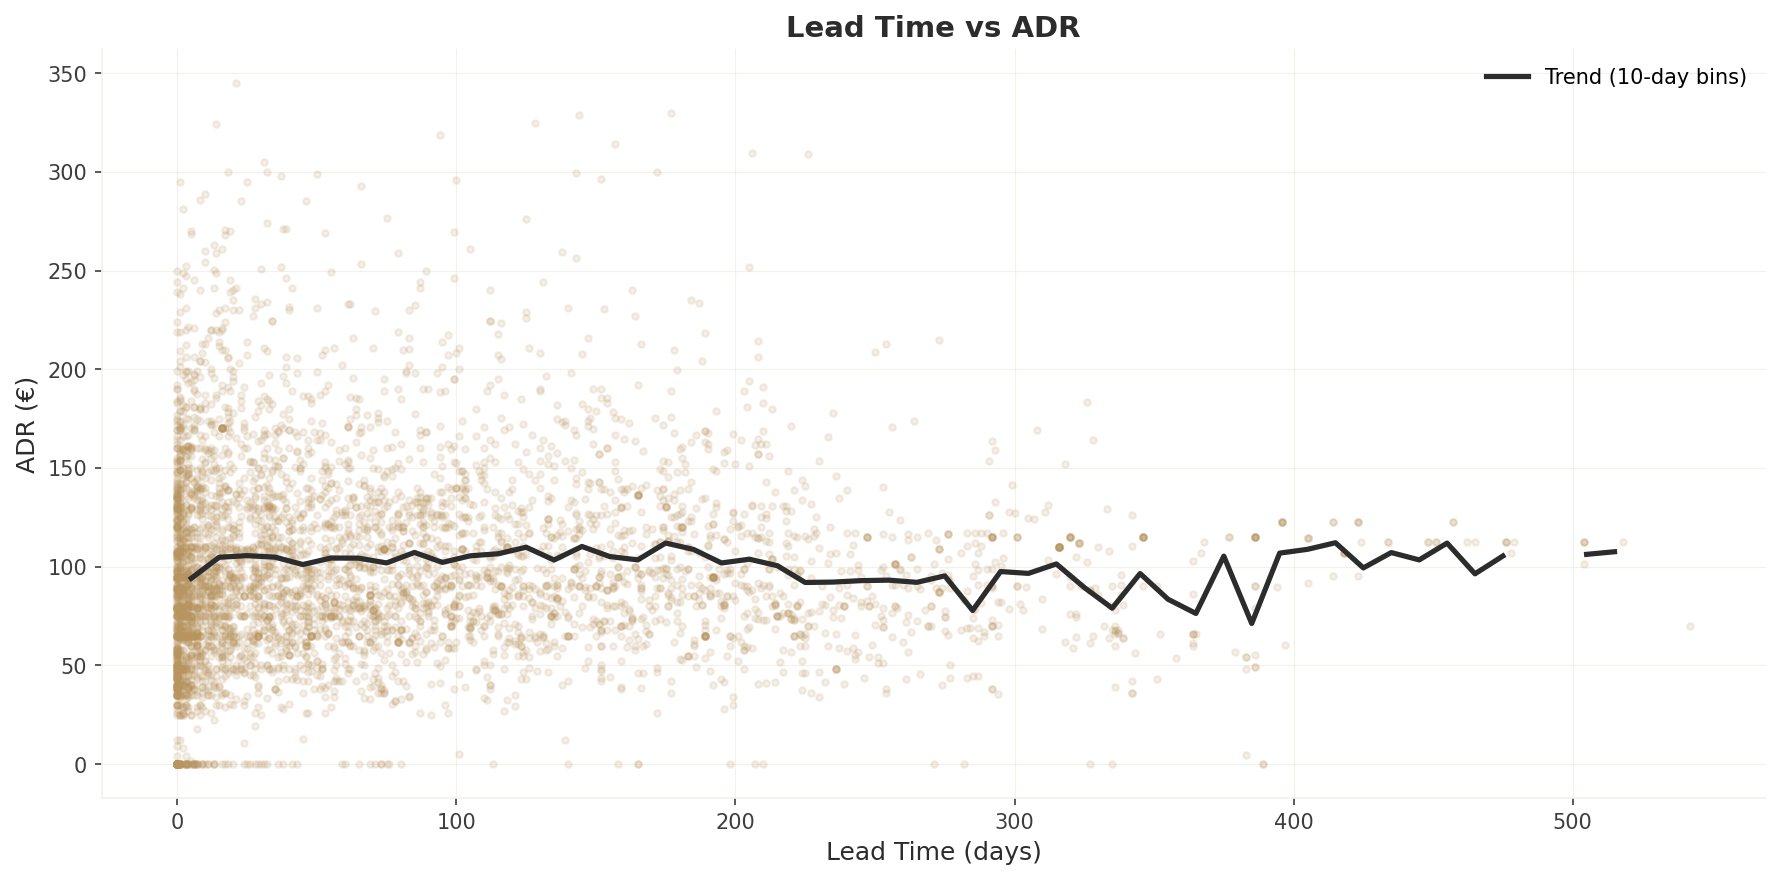

In [3]:
# Lead time vs ADR scatter with trend line
sample = active[active['adr'] < 400].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(sample['lead_time'], sample['adr'], alpha=0.15, s=10, color=COLORS['primary'])

# Add rolling average trend
lead_bins = np.arange(0, sample['lead_time'].max(), 10)
trend = active[active['adr'] < 400].groupby(pd.cut(active['lead_time'], bins=lead_bins))['adr'].mean()
bin_centers = [(b.left + b.right) / 2 for b in trend.index]
ax.plot(bin_centers, trend.values, color=COLORS['dark'], linewidth=2.5, label='Trend (10-day bins)')

ax.set_title('Lead Time vs ADR', fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('ADR (€)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}13_leadtime_vs_adr.png')
plt.show()

## 3. Seasonal Price Patterns

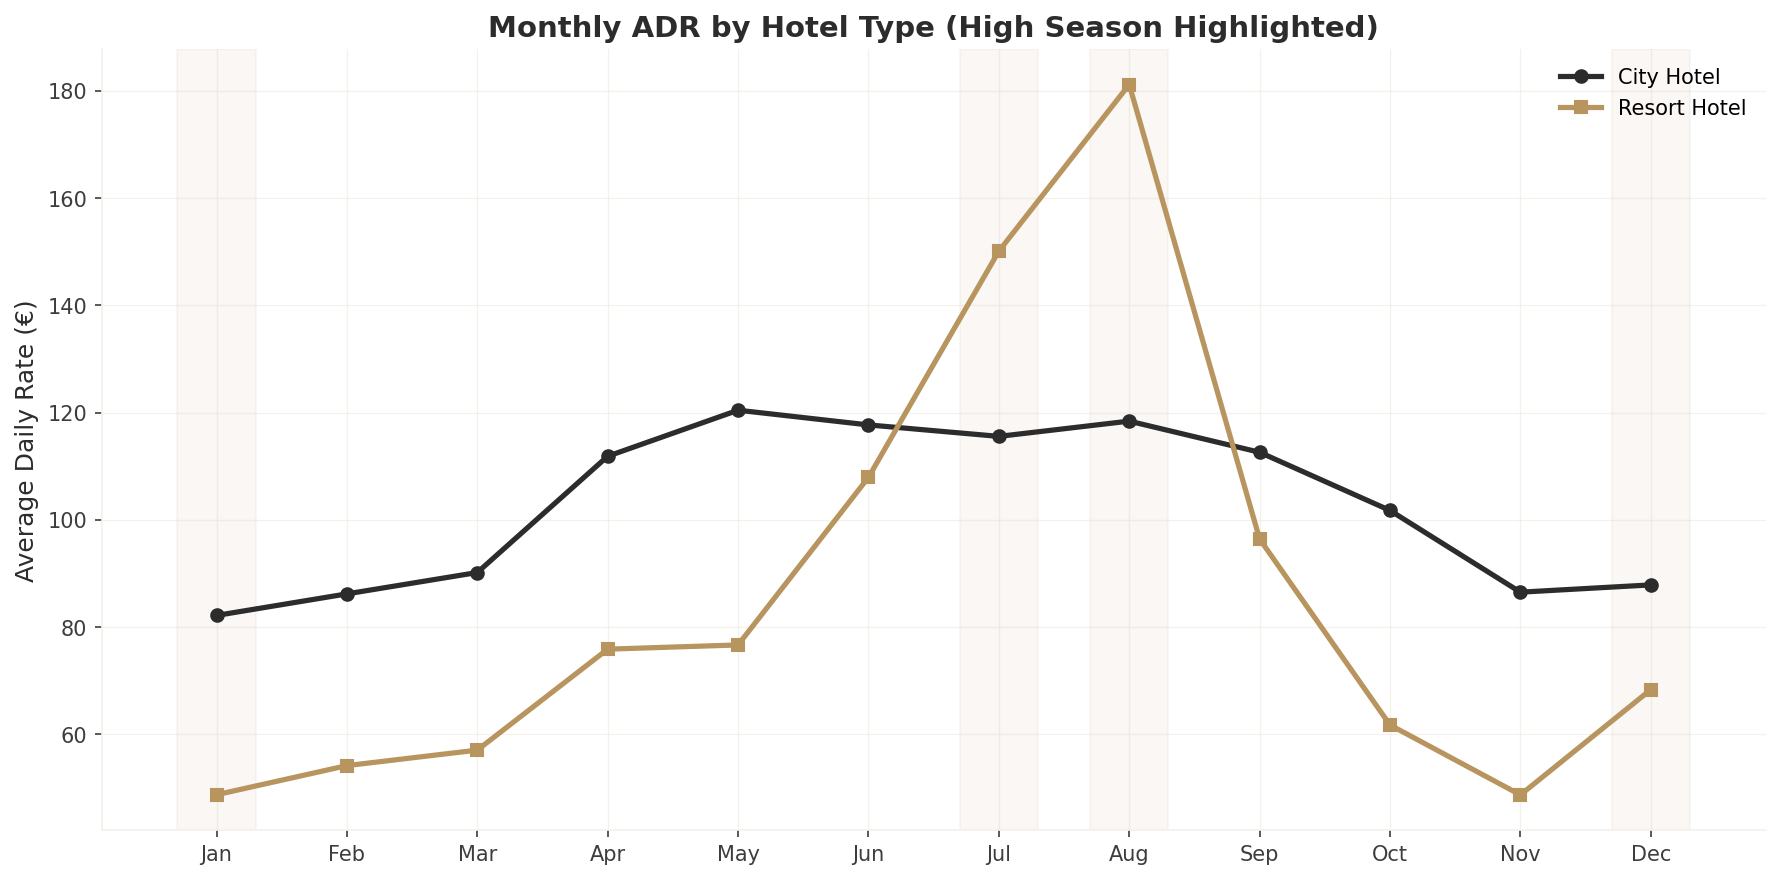

In [4]:
# Monthly ADR by hotel type
monthly_adr = active.groupby(['arrival_date_month', 'hotel'])['adr'].mean().unstack()
monthly_adr = monthly_adr.reindex(MONTH_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(12), monthly_adr['City Hotel'], color=COLORS['dark'], marker='o',
        linewidth=2.5, label='City Hotel')
ax.plot(range(12), monthly_adr['Resort Hotel'], color=COLORS['primary'], marker='s',
        linewidth=2.5, label='Resort Hotel')

# Highlight high season
for m in [0, 6, 7, 11]:  # Jan, Jul, Aug, Dec
    ax.axvspan(m - 0.3, m + 0.3, alpha=0.1, color=COLORS['accent'])

ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_title('Monthly ADR by Hotel Type (High Season Highlighted)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Daily Rate (€)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}14_seasonal_adr.png')
plt.show()

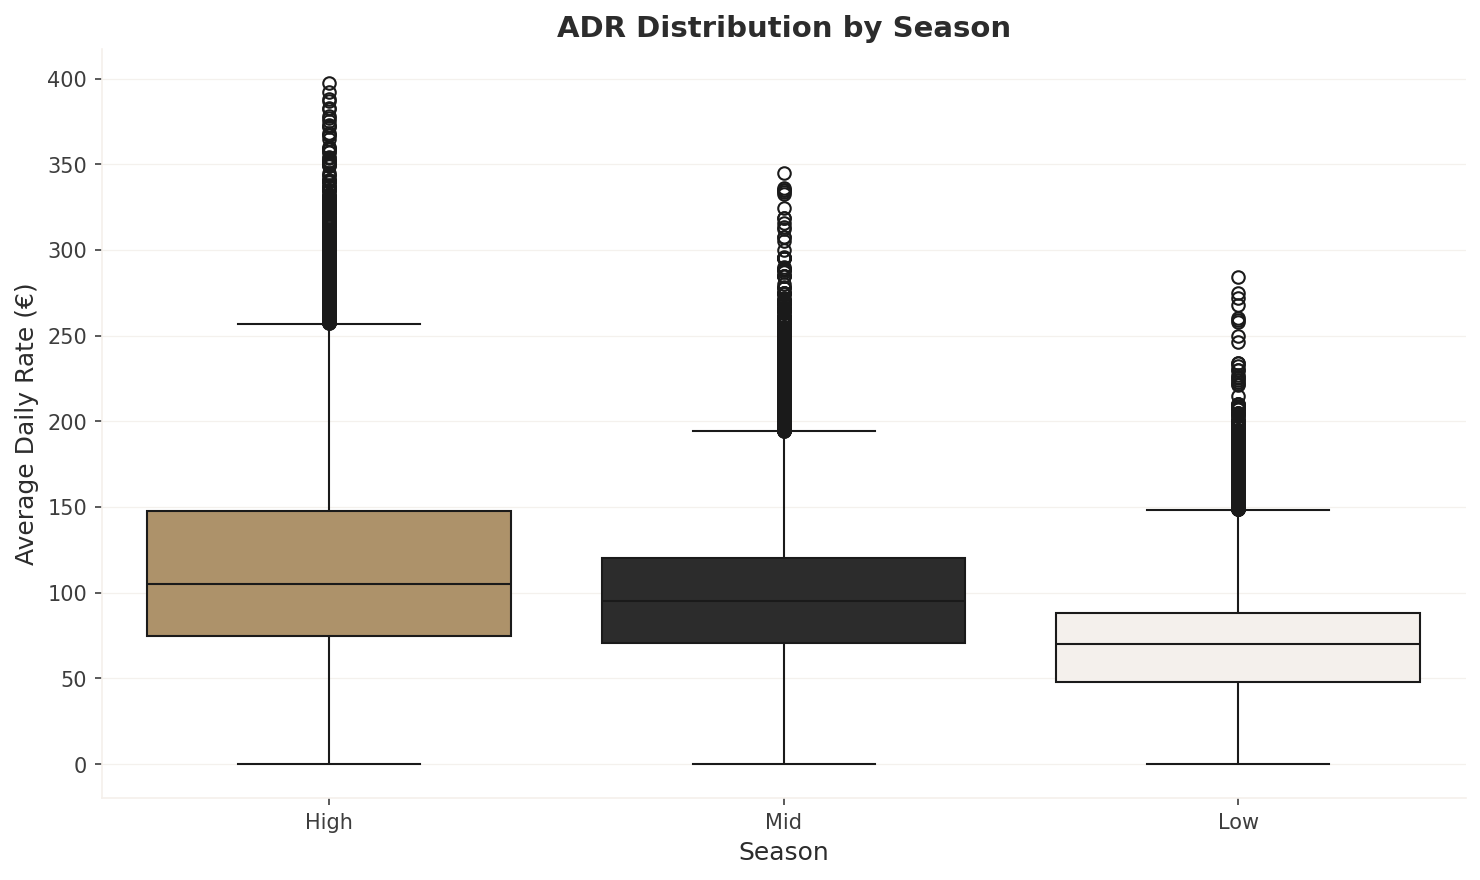

In [5]:
# ADR distribution by season
fig, ax = plt.subplots(figsize=(10, 6))
season_order = ['High', 'Mid', 'Low']
sns.boxplot(
    data=active[active['adr'] < 400],
    x='season', y='adr', order=season_order,
    palette=[COLORS['primary'], COLORS['dark'], COLORS['light_gray']],
    ax=ax
)
ax.set_title('ADR Distribution by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Daily Rate (€)')
ax.set_xlabel('Season')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}15_adr_by_season.png')
plt.show()

## 4. Price Elasticity by Segment

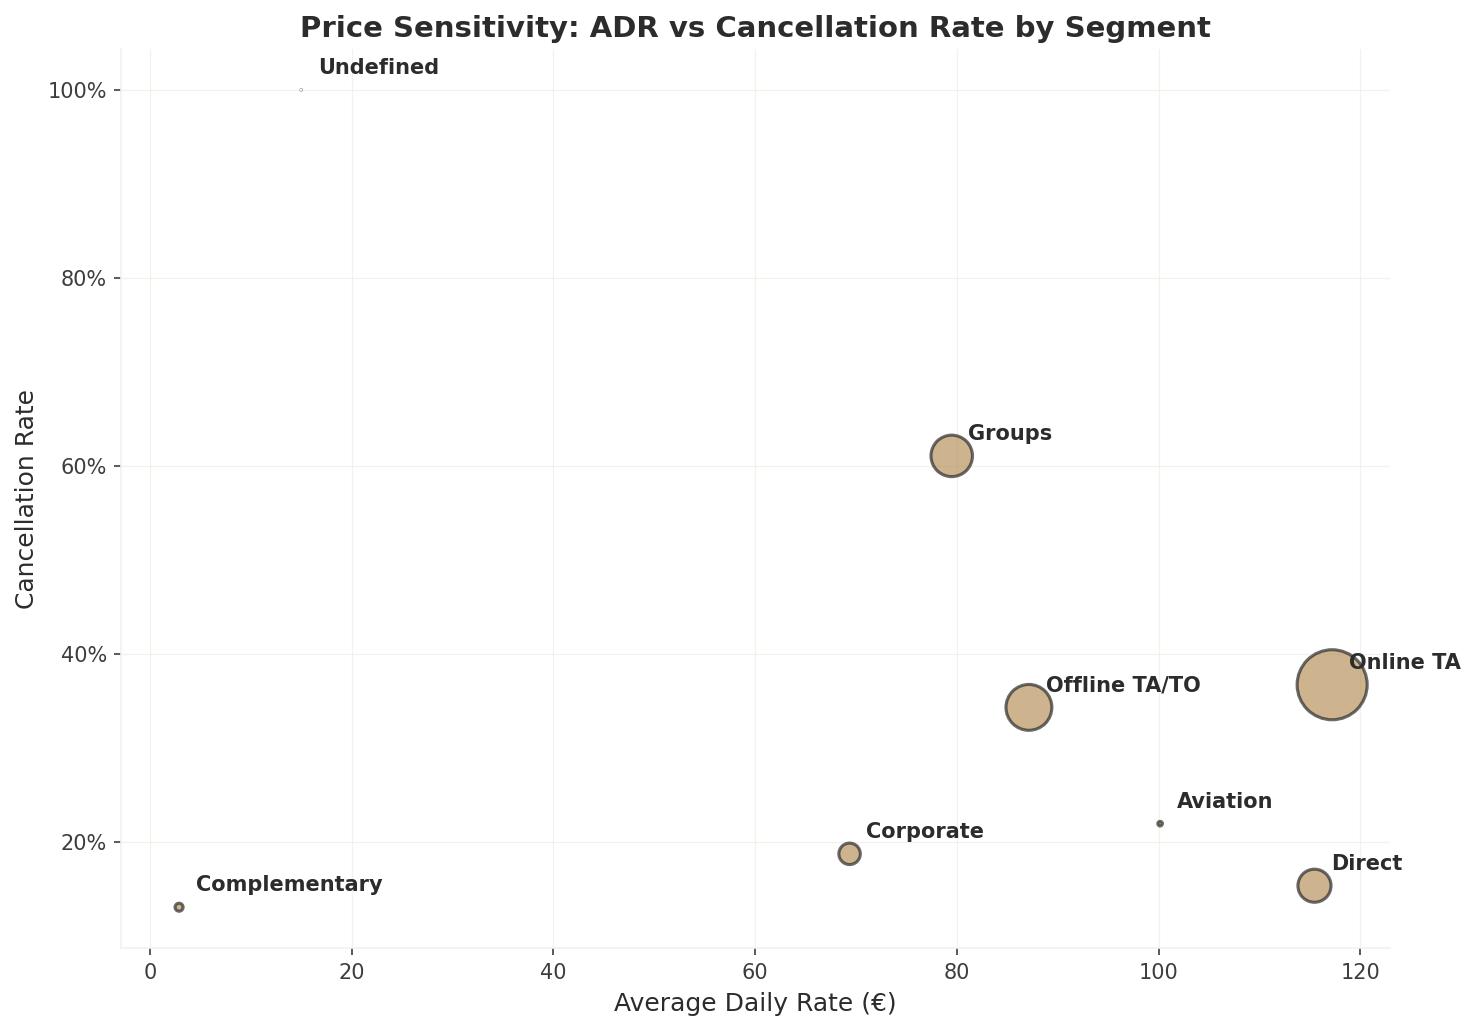

In [6]:
# ADR vs Cancellation Rate by market segment
segment_pricing = df.groupby('market_segment').agg(
    avg_adr=('adr', 'mean'),
    cancel_rate=('is_canceled', 'mean'),
    bookings=('is_canceled', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    segment_pricing['avg_adr'],
    segment_pricing['cancel_rate'],
    s=segment_pricing['bookings'] / 50,
    color=COLORS['primary'], alpha=0.7, edgecolors=COLORS['dark'], linewidth=1.5
)
for _, row in segment_pricing.iterrows():
    ax.annotate(row['market_segment'],
                (row['avg_adr'], row['cancel_rate']),
                textcoords='offset points', xytext=(8, 8),
                fontsize=10, fontweight='bold', color=COLORS['dark'])
ax.set_title('Price Sensitivity: ADR vs Cancellation Rate by Segment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Daily Rate (€)')
ax.set_ylabel('Cancellation Rate')
from src.viz_style import format_axis_pct
format_axis_pct(ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}16_price_elasticity.png')
plt.show()

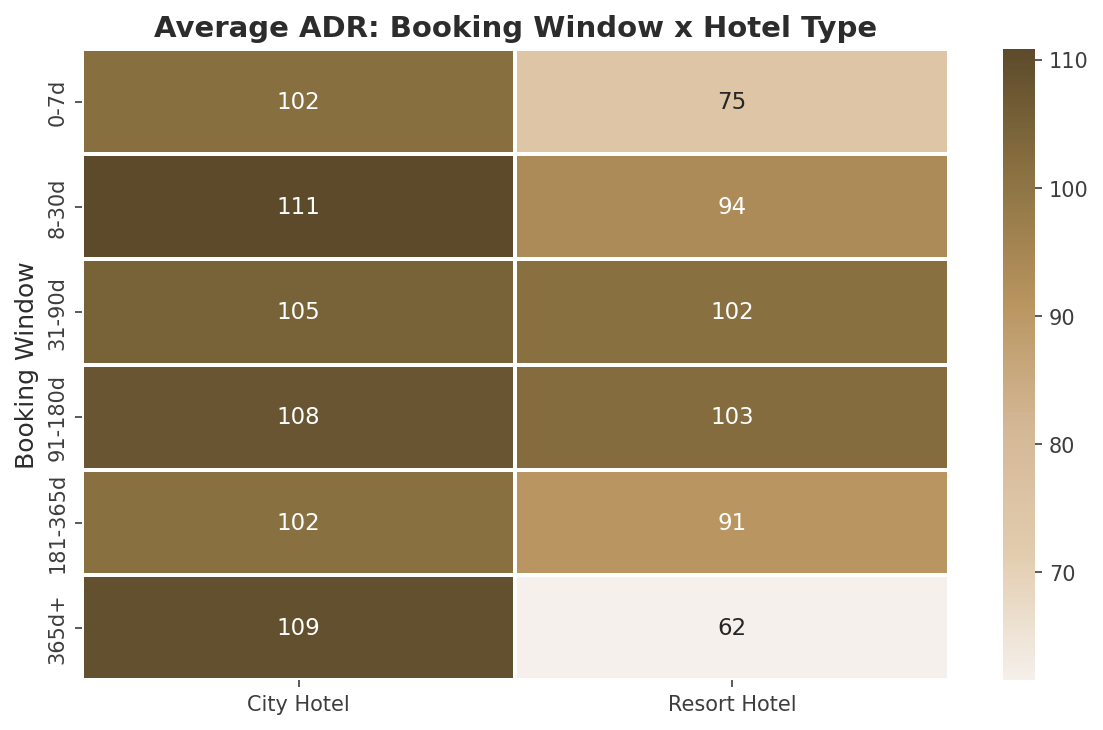

In [7]:
# ADR by booking window AND hotel type — heatmap
pivot = active.groupby(['booking_window', 'hotel'], observed=False)['adr'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap=GOLD_CMAP, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Average ADR: Booking Window x Hotel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Booking Window')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}17_adr_heatmap.png')
plt.show()

## 5. Optimal Pricing Windows

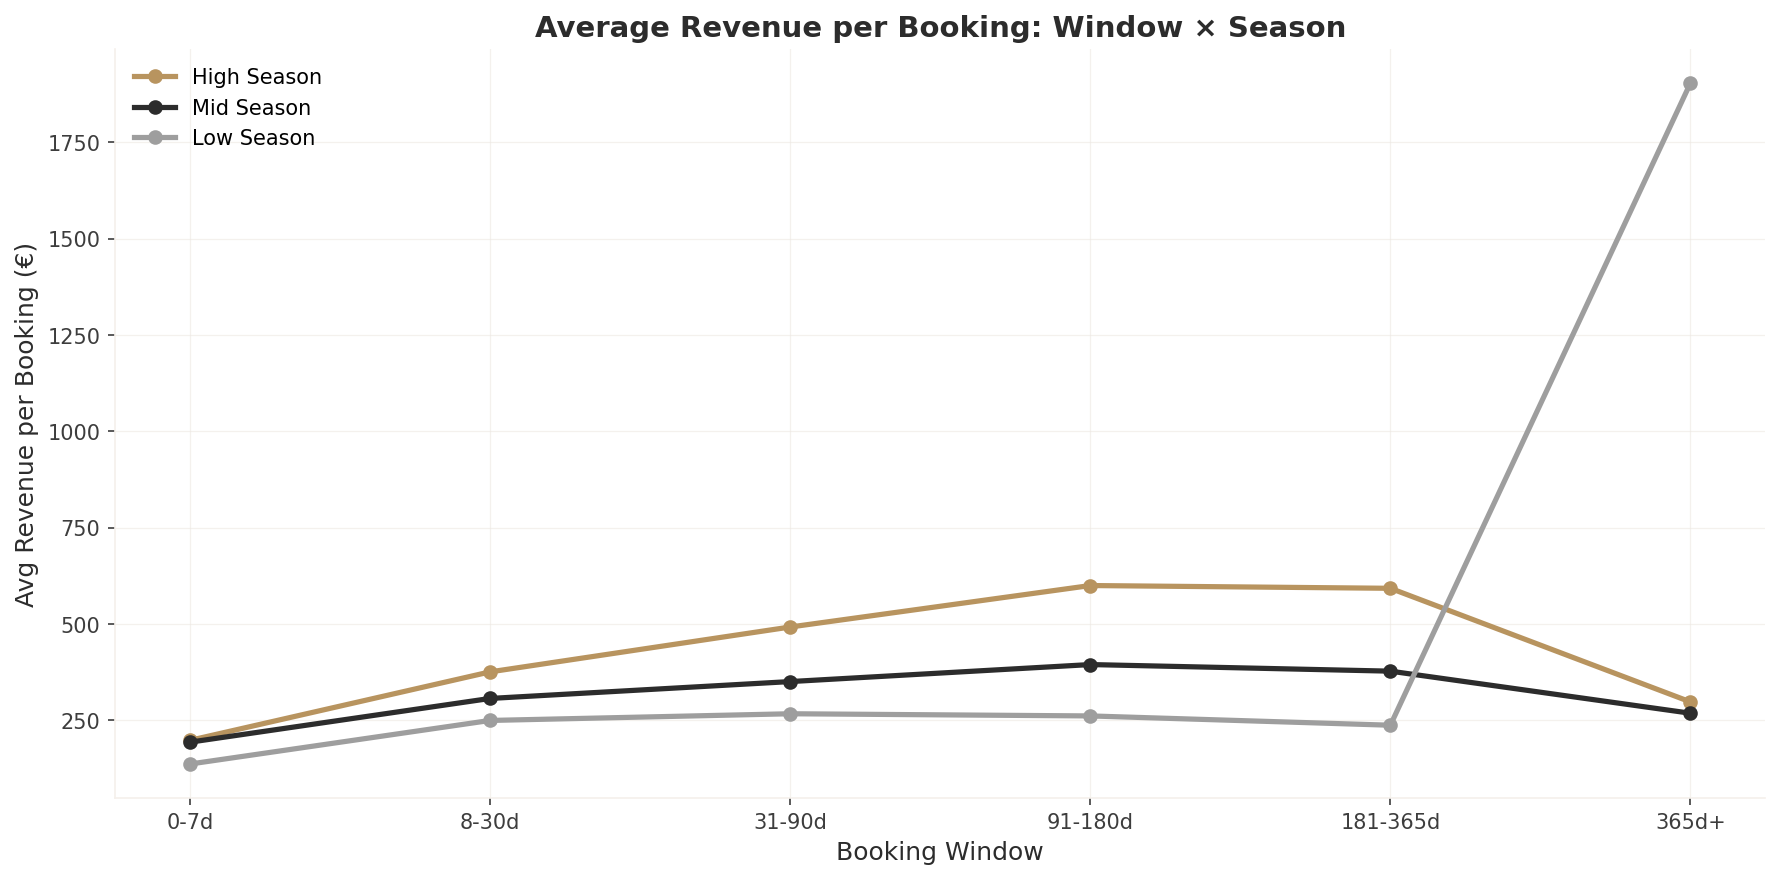

In [8]:
# Revenue per booking by window and season
rev_window = active.groupby(['booking_window', 'season'], observed=False).agg(
    avg_revenue=('total_revenue', 'mean'),
    avg_adr=('adr', 'mean'),
    bookings=('hotel', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
season_colors = {'High': COLORS['primary'], 'Mid': COLORS['dark'], 'Low': COLORS['muted']}
for season in ['High', 'Mid', 'Low']:
    mask = rev_window['season'] == season
    ax.plot(rev_window.loc[mask, 'booking_window'].astype(str),
            rev_window.loc[mask, 'avg_revenue'],
            marker='o', linewidth=2.5, label=f'{season} Season',
            color=season_colors[season])

ax.set_title('Average Revenue per Booking: Window × Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Booking Window')
ax.set_ylabel('Avg Revenue per Booking (€)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}18_revenue_window_season.png')
plt.show()

## 6. Pricing Strategy Recommendations

### Key Findings
- **Short lead-time bookings (0–7 days)** command higher ADR — these are often last-minute business or urgent travelers with lower price sensitivity.
- **Resort Hotels** show strong seasonal pricing variation (peak in summer), while **City Hotels** maintain more stable rates year-round.
- **High-season pricing opportunity** — there's significant room to increase rates in Jul/Aug, especially for resort properties.

### Recommended Pricing Strategy
1. **Lead-time dynamic pricing:**
   - 0–7 days: Premium rate (current + 10–15%)
   - 8–30 days: Standard rate
   - 31–90 days: Early-bird rate (discount 5–8% to capture demand)
   - 90+ days: Lock-in rate (require deposit + moderate discount)
2. **Seasonal multipliers:** Apply 15–25% premium during high season for resort hotels.
3. **Segment-specific pricing:** Online TA segment is price-sensitive with high cancellation — consider non-refundable rate options at 10% discount.

---
*Next: [04_Customer_Value_Segmentation.ipynb](04_Customer_Value_Segmentation.ipynb) — Customer clustering & targeting.*